# Vibe 25 — Is this cooling valve hunting?

For **controls technicians**. We look at one analog output (cooling valve %) and ask:

> Is the valve settling, or is it swinging back and forth for a long time?

Open-FDD rule **PID-HUNT-1** is a screening tool. A flag means *suspected hunting* — not automatic proof that PID gains are wrong.

Helper code lives in Python modules under `vibe25/` (you import it; you do not need to read the math source).


## Install (once)

```text
pip install "open-fdd[oracle]" matplotlib
```

Or from this folder: `pip install -e ".[dev]"`


In [1]:
%pip install -q "open-fdd[oracle]>=4.4.1" matplotlib


Note: you may need to restart the kernel to use updated packages.


In [2]:
from vibe25 import (
    fault_summary,
    healthy_cooling_valve,
    hunting_sine_cooling_valve,
    plot_healthy_vs_hunting,
    plot_valve_overview,
    plot_valve_zoom_with_tv,
    run_pid_hunt,
)
import matplotlib.pyplot as plt


## 1. What hunting looks like (synthetic trends)

Left: a **healthy** valve that slowly opens — the kind of trend you want after a load change.

Right: a **hunting** sine wave — the command keeps oscillating instead of settling.


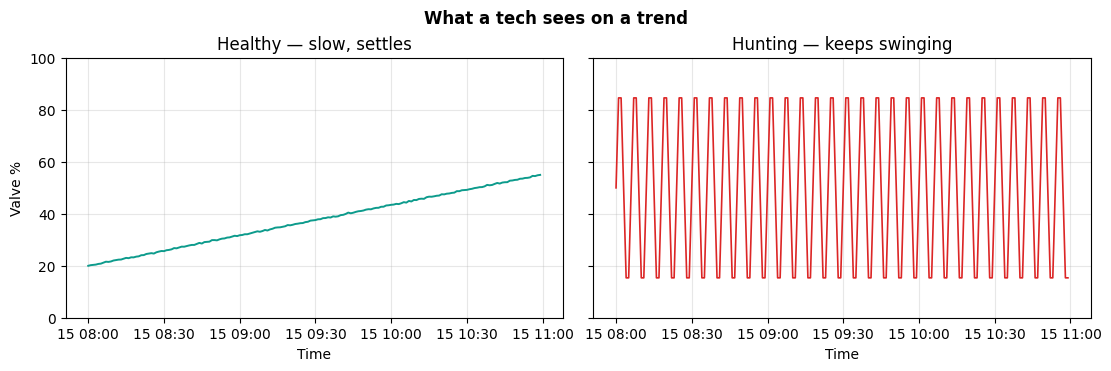

In [3]:
healthy = healthy_cooling_valve()
hunting = hunting_sine_cooling_valve()  # swinging sine wave

fig = plot_healthy_vs_hunting(healthy, hunting)
plt.show()


## 2. Full hunting trend

Same hunting sine, full length. Pink band = times Open-FDD would call **hunting** on a rolling 1-hour window.


{'any_fault': True, 'fault_minutes': 133, 'max_tv_1h': 1385.6406460551038, 'max_span_1h': 69.2820323027561}


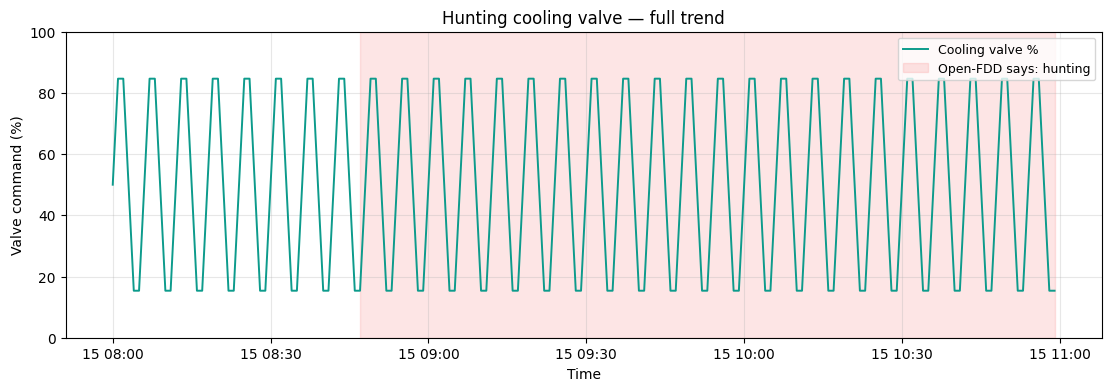

In [4]:
metrics = run_pid_hunt(hunting)
print(fault_summary(metrics))

fig = plot_valve_overview(hunting, metrics, title="Hunting cooling valve — full trend")
plt.show()


## 3. Zoom in — what is TV?

**Span** = high minus low on the wiggle (how tall the swing is).

**TV (total variation)** = add up *every* move (up and down), like an odometer for the valve command.

Open-FDD adds those moves over about **one hour**. If the valve travels too far, too often, it flags hunting.

The zoom below shows **3 cycles**. Blue arrows are individual moves. Those numbers **add up** to TV.


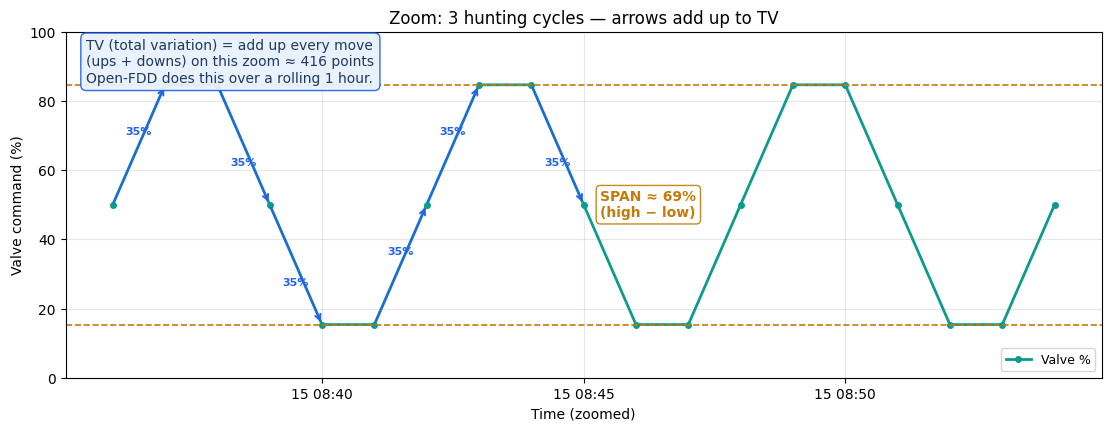

In [5]:
fig = plot_valve_zoom_with_tv(
    hunting,
    start_sample=36,
    n_cycles=3,
    period_samples=6,
    title="Zoom: 3 hunting cycles — arrows add up to TV",
)
plt.show()


## 4. Healthy check (should stay clear)

Same detector on the slow ramp. You should see **no** hunting flag and a tiny TV.


{'any_fault': False, 'fault_minutes': 0, 'max_tv_1h': 0.0, 'max_span_1h': 12.089720823223054}


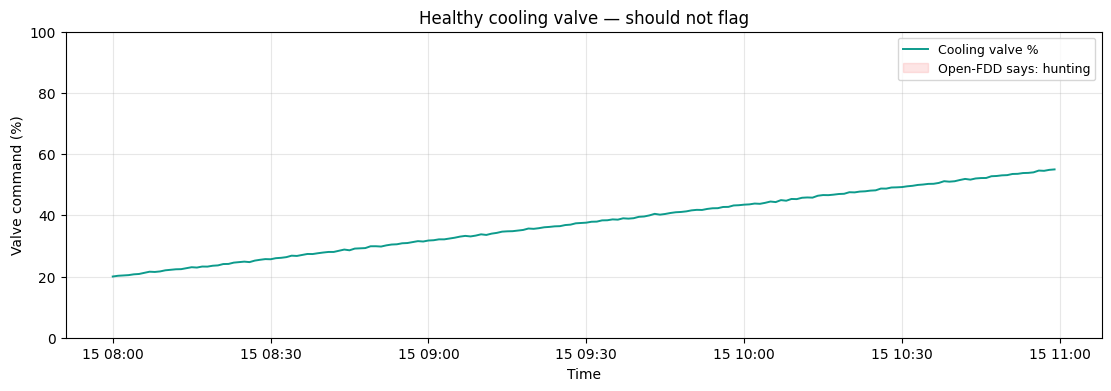

In [6]:
ok_metrics = run_pid_hunt(healthy)
print(fault_summary(ok_metrics))

fig = plot_valve_overview(healthy, ok_metrics, title="Healthy cooling valve — should not flag")
plt.show()


## Tech takeaways

| Word | Plain English |
|------|----------------|
| Valve % | Analog command / position (0–100) |
| Span | High − low of the swing |
| TV | Total travel (sum of ups and downs) |
| Hunting flag | Too much travel for too long (rolling ~1 hour) |

Use this on real historian data the same way: put valve % on a time index, call `run_pid_hunt(df)`.

Helper modules: `vibe25.synth`, `vibe25.detect`, `vibe25.plotting`.
